   Enrollment no       District               Locality    pH     TDS  \
0           43.0  Central Delhi  Hostel, Kashmere gate  7.63  2063.0   
1           56.0  Central Delhi  Hostel, Kashmere Gate  7.63  2063.0   
2           61.0  Central Delhi          Kashmere Gate  7.57   441.0   
3           64.0  Central Delhi         Kashmiri  Gate  7.64    17.2   
4           65.0  Central delhi         kashmere Gate   7.68   433.0   

   Conductivity  
0        4030.0  
1        4030.0  
2         717.0  
3         407.0  
4         378.0  
Enrollment no    0
District         0
Locality         0
pH               0
TDS              0
Conductivity     0
dtype: int64
['central delhi' 'east delhi' 'faridabad' 'gurgaon' 'north delhi'
 'north west delhi' 'south delhi' 'south-west delhi' 'west delhi']


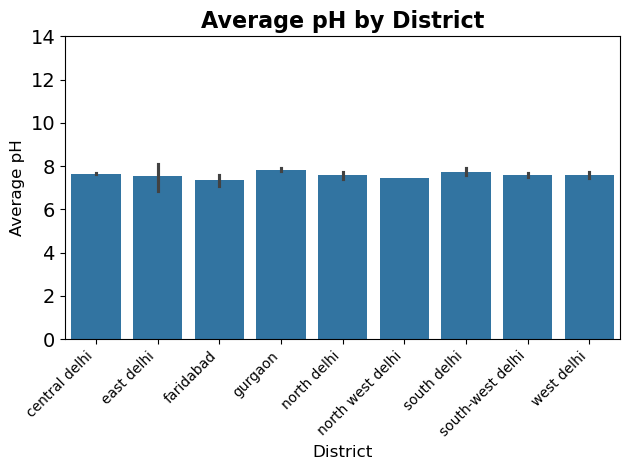

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load the CSV file
df = pd.read_csv('/Users/anoushka/Desktop/sample.csv', header=2)

# Step 2: Assign meaningful column names
df.columns = ['Enrollment no', 'District', 'Locality', 'pH', 'TDS', 'Conductivity']

# Step 3: Clean the column names by stripping spaces (if any)
df.columns = df.columns.str.strip()

# Step 4: Check the first few rows to ensure the data looks correct
print(df.head())

# Step 5: Data Cleaning (remove any rows with missing values in key columns)
df = df.dropna(subset=['District', 'Locality', 'pH', 'TDS', 'Conductivity'])

# Step 6: Convert relevant columns to numeric
df['pH'] = pd.to_numeric(df['pH'], errors='coerce')
df['TDS'] = pd.to_numeric(df['TDS'], errors='coerce')
df['Conductivity'] = pd.to_numeric(df['Conductivity'], errors='coerce')

# Step 7: Check for missing values after conversion
print(df.isnull().sum())

df['District'] = df['District'].str.lower()  # Convert all to lowercase

# Replace the specific cases
df['District'] = df['District'].replace({
    'central delhi': 'central delhi',  # Ensure uniform naming for Central Delhi
    'south west delhi': 'south-west delhi'  # Normalize South West Delhi variations
})

# Normalize District names
df['District'] = df['District'].str.lower()  # Convert all to lowercase
df['District'] = df['District'].str.strip()  # Remove any leading/trailing whitespaces

# Replace the specific cases (for both Central Delhi and South West Delhi variations)
df['District'] = df['District'].replace({
    'central delhi': 'central delhi',  # Ensure uniform naming for Central Delhi
    'south west delhi': 'south-west delhi',  # Normalize South West Delhi variations
    'south-west delhi': 'south-west delhi',
    'south west delhi': 'south-west delhi'
})

# Check the unique values of the 'District' column to confirm no duplicates
print(df['District'].unique())


sns.barplot(x='District', y='pH', data=df, color='#1f77b4')

# Customize the title and labels
plt.title('Average pH by District', fontsize=16, fontweight='bold')
plt.xlabel('District', fontsize=12)
plt.ylabel('Average pH', fontsize=12)

# Set the range for the y-axis (appropriate for pH values)
plt.ylim(0, 14)  # pH values range from 0 to 14

# Customize tick size for better readability
plt.tick_params(axis='y', labelsize=14)  # Increase the size of y-axis labels
plt.xticks(rotation=45, ha='right')

# Show the plot
plt.tight_layout()
plt.show()




/var/folders/__/yfxhqrzd2z949577b8zj_v9c0000gn/T/ipykernel_50163/794866304.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='District', y='TDS', data=df, ci=None, color='#0496C7')


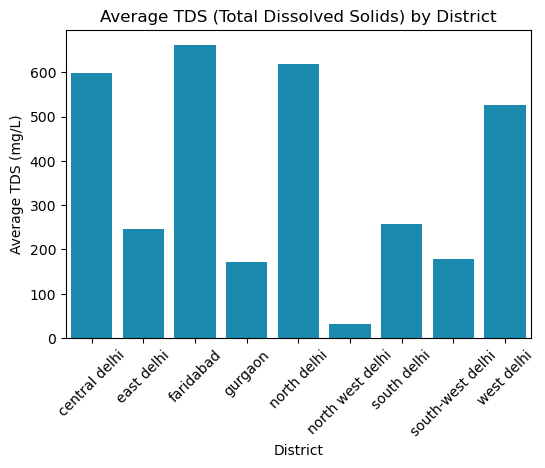

In [49]:
# Step 2: Bar chart for the average TDS by District
plt.figure(figsize=(6, 4))
sns.barplot(x='District', y='TDS', data=df, ci=None, color='#0496C7')
plt.title('Average TDS (Total Dissolved Solids) by District')
plt.xlabel('District')
plt.ylabel('Average TDS (mg/L)')
plt.xticks(rotation=45)
plt.show()

/var/folders/__/yfxhqrzd2z949577b8zj_v9c0000gn/T/ipykernel_50163/3833012528.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='District', y='Conductivity', data=df, ci=None)


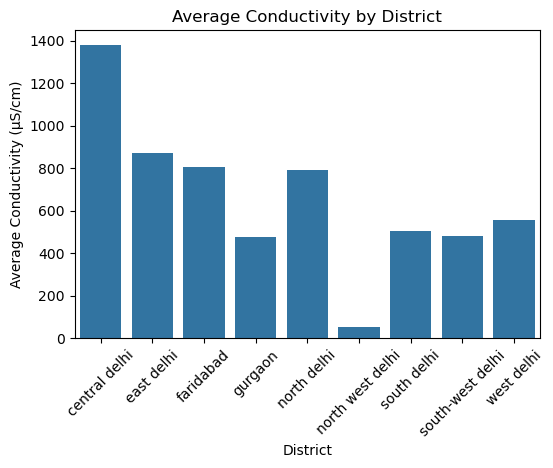

In [35]:
# Step 3: Bar chart for the average Conductivity by District
plt.figure(figsize=(6, 4))
sns.barplot(x='District', y='Conductivity', data=df, ci=None,)
plt.title('Average Conductivity by District')
plt.xlabel('District')
plt.ylabel('Average Conductivity (µS/cm)')
plt.xticks(rotation=45)
plt.show()